<a href="https://colab.research.google.com/github/erknoztk/capstone/blob/master/cs1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [125]:
import pandas as pd

df = pd.read_csv("cp1/social_media_comments.csv", encoding="cp1254")# cp124 windows TURKISH

In [126]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11119 entries, 0 to 11118
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Tip       11119 non-null  object
 1   Paylaşım  11117 non-null  object
dtypes: object(2)
memory usage: 173.9+ KB


In [127]:
df.isnull().sum()

,0
Tip,0
Paylaşım,2


In [128]:
df["Tip"].value_counts()

,count
Tip,
Pozitif,6115
Negatif,5004


In [150]:
import pandas as pd

df = pd.read_csv("cp1/social_media_comments.csv", encoding="cp1254")

df.shape
df.info()
df.isnull().sum()
df["Tip"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11119 entries, 0 to 11118
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Tip       11119 non-null  object
 1   Paylaşım  11117 non-null  object
dtypes: object(2)
memory usage: 173.9+ KB


,count
Tip,
Pozitif,6115
Negatif,5004


In [129]:
df["text_length"] = df["Paylaşım"].astype(str).apply(len) # char length

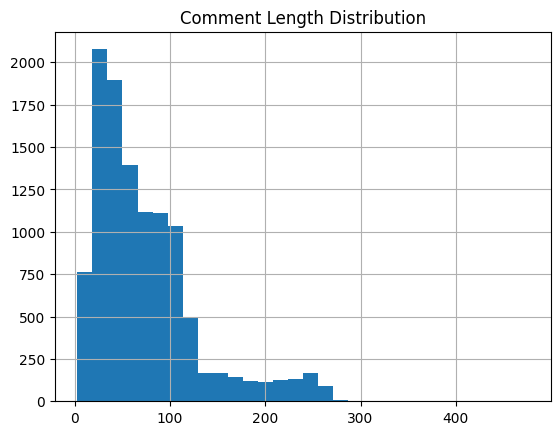

In [130]:
import matplotlib.pyplot as plt

df["text_length"].hist(bins=30)
plt.title("Comment Length Distribution")
plt.show()

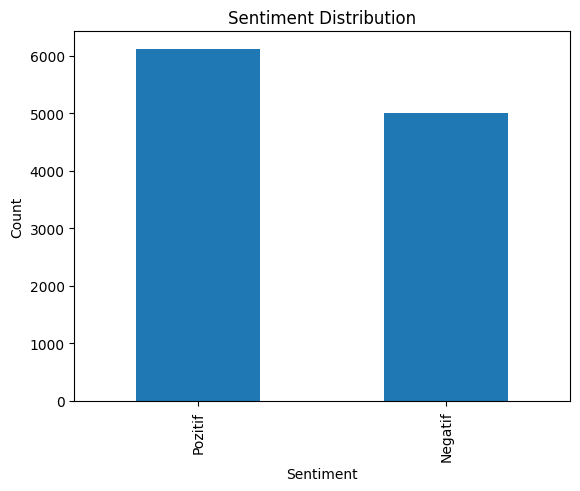

In [131]:
import matplotlib.pyplot as plt
# SENTIMENT DISTRIBUTION
df["Tip"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

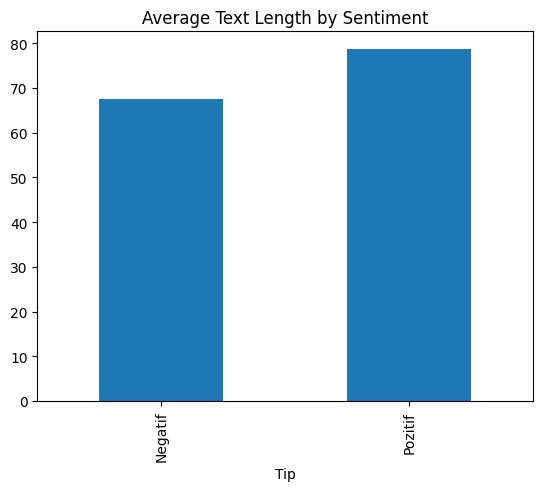

In [132]:
df["text_length"] = df["Paylaşım"].astype(str).apply(len)
#avg text LENGTH according to  "TİP"
df.groupby("Tip")["text_length"].mean().plot(kind="bar")
plt.title("Average Text Length by Sentiment")
plt.show()

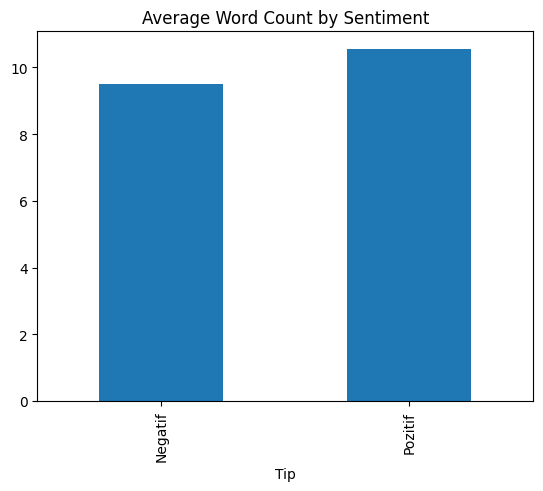

In [133]:
df["word_count"] = df["Paylaşım"].astype(str).apply(lambda x: len(x.split()))
# avg word count according to "TİP"
df.groupby("Tip")["word_count"].mean().plot(kind="bar")
plt.title("Average Word Count by Sentiment")
plt.show()

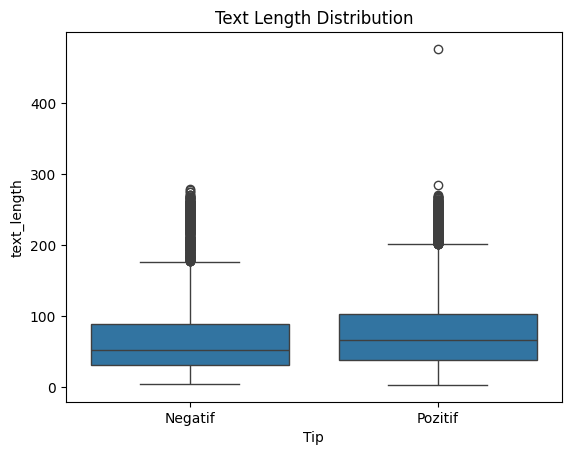

In [134]:
import seaborn as sns

sns.boxplot(x="Tip", y="text_length", data=df)
plt.title("Text Length Distribution")
plt.show()

In [135]:
import re

#lowercase yapıldı
#linkler kaldırıldı
#noktalama temizlendi
#noise azaltıldı
#
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Zğüşıöç ]", "", text)
    return text

df["clean_text"] = df["Paylaşım"].apply(clean_text)

In [136]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_text"])
y = df["Tip"]

MODEL PART METHOD SECTION
Neden Logistic Regression?
NLP için güçlü baseline
hızlı
sparse data (TF-IDF) ile iyi çalışır
📌 Neden Naive Bayes?
text classification için klasik
küçük veri için iyi
📌 Neden SVM?
high dimensional data’da güçlü

In [137]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [138]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [139]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

In [140]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

In [141]:
from sklearn.metrics import accuracy_score

print("LogReg:", accuracy_score(y_test, pred_lr))
print("Naive Bayes:", accuracy_score(y_test, pred_nb))
print("SVM:", accuracy_score(y_test, pred_svm))

LogReg: 0.8502697841726619
Naive Bayes: 0.8466726618705036
SVM: 0.8471223021582733


In [142]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

models = {
    "LogReg": pred_lr,
    "NaiveBayes": pred_nb,
    "SVM": pred_svm
}

for name, pred in models.items():
    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred, average="weighted"),
        recall_score(y_test, pred, average="weighted"),
        f1_score(y_test, pred, average="weighted")
    ])

import pandas as pd

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-score"
])

results_df

,Model,Accuracy,Precision,Recall,F1-score
0,LogReg,0.850270,0.856365,0.850270,0.848418
1,NaiveBayes,0.846673,0.847355,0.846673,0.846033
2,SVM,0.847122,0.847905,0.847122,0.846452


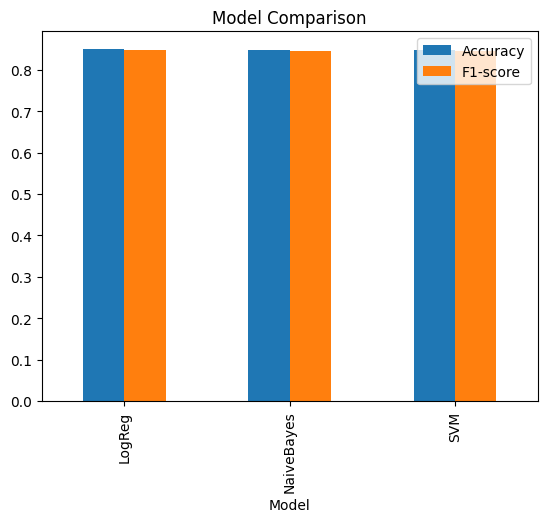

In [143]:
results_df.set_index("Model")[["Accuracy","F1-score"]].plot(kind="bar")
plt.title("Model Comparison")
plt.show()

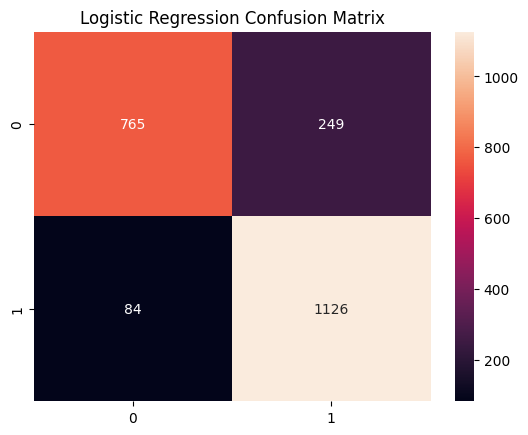

In [144]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred_lr)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [145]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

vectorizer = TfidfVectorizer(ngram_range=(1,2))

X = vectorizer.fit_transform(df["clean_text"])
y = df["Tip"]   # 🔥 dikkat

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000)

In [146]:
new_comment = "sevdim"

new_comment_clean = clean_text(new_comment)
new_vector = vectorizer.transform([new_comment_clean])

prediction = model.predict(new_vector)

if prediction[0] == "positive":
    print("😊 Positive sentiment")
else:
    print("😡 Negative sentiment")

😡 Negative sentiment


📊 MODEL RESULTS:
        Model  Accuracy  Precision    Recall  F1-score
0      LogReg  0.850270   0.856365  0.850270  0.848418
1  NaiveBayes  0.846673   0.847355  0.846673  0.846033
2         SVM  0.847122   0.847905  0.847122  0.846452


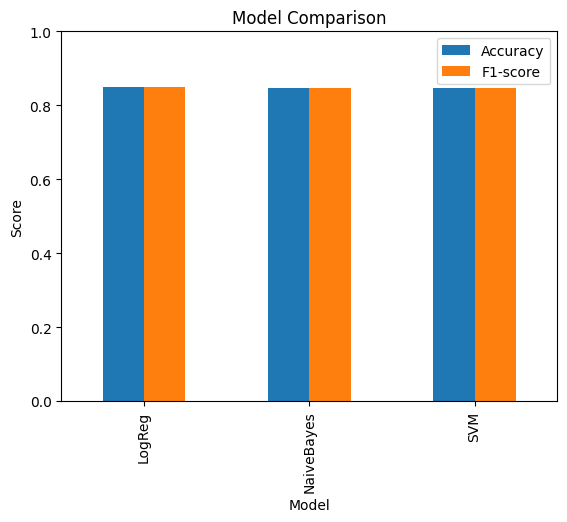

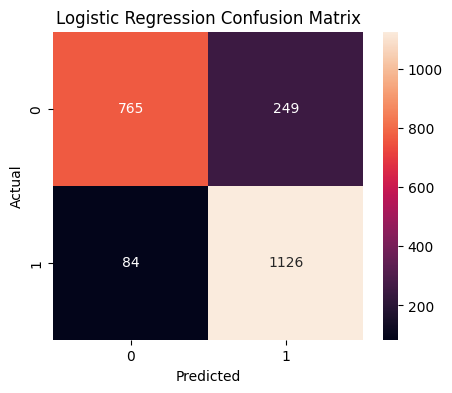

📌 Logistic Regression Report:
              precision    recall  f1-score   support

     Negatif       0.90      0.75      0.82      1014
     Pozitif       0.82      0.93      0.87      1210

    accuracy                           0.85      2224
   macro avg       0.86      0.84      0.85      2224
weighted avg       0.86      0.85      0.85      2224



In [147]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# --- MODEL PREDICTIONS ALREADY EXIST ---
# pred_lr, pred_nb, pred_svm
# y_test

# -----------------------------
# 1. METRICS TABLE
# -----------------------------
results = pd.DataFrame({
    "Model": ["LogReg", "NaiveBayes", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_nb),
        accuracy_score(y_test, pred_svm)
    ],
    "Precision": [
        precision_score(y_test, pred_lr, average="weighted"),
        precision_score(y_test, pred_nb, average="weighted"),
        precision_score(y_test, pred_svm, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, pred_lr, average="weighted"),
        recall_score(y_test, pred_nb, average="weighted"),
        recall_score(y_test, pred_svm, average="weighted")
    ],
    "F1-score": [
        f1_score(y_test, pred_lr, average="weighted"),
        f1_score(y_test, pred_nb, average="weighted"),
        f1_score(y_test, pred_svm, average="weighted")
    ]
})

print("📊 MODEL RESULTS:")
print(results)

# -----------------------------
# 2. BAR PLOT COMPARISON
# -----------------------------
results.set_index("Model")[["Accuracy", "F1-score"]].plot(kind="bar")
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()

# -----------------------------
# 3. CONFUSION MATRIX (BEST MODEL = LR)
# -----------------------------
cm = confusion_matrix(y_test, pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# 4. CLASSIFICATION REPORT (BEST MODEL)
# -----------------------------
print("📌 Logistic Regression Report:")
print(classification_report(y_test, pred_lr))

In [148]:
def predict_sentiment(text):

    cleaned = clean_text(text)

    vector = vectorizer.transform([cleaned])

    prediction = model.predict(vector)

    if prediction[0] == "positive":
        print("😊 Positive sentiment")
    else:
        print("😡 Negative sentiment")

# TEST
predict_sentiment("bunu çok beğendim")

😡 Negative sentiment


In [ ]:
while True:
    text = input("Yorum yaz (çıkmak için q): ")

    if text == "q":
        break

    cleaned = clean_text(text)
    vector = vectorizer.transform([cleaned])
    prediction = model.predict(vector)

    print("Sonuç:", prediction[0])

Yorum yaz (çıkmak için q): çook seviyorum
Sonuç: Pozitif
Yorum yaz (çıkmak için q): yapılan yorumlara takılma
Sonuç: Pozitif
Yorum yaz (çıkmak için q): çöp diye laf atıcagınıza sizinde bir çğpünüz olsun önce
Sonuç: Pozitif
Yorum yaz (çıkmak için q): soytarı herifler sizi
Sonuç: Negatif
Yorum yaz (çıkmak için q): üreten insana saygı
Sonuç: Pozitif
Yorum yaz (çıkmak için q): boş insal boş laf yalaka herif seni
Sonuç: Negatif
Yorum yaz (çıkmak için q): soytarı kahpe seni 
Sonuç: Negatif
